# SEIS-763 Group Project include group member names with an introduction explaining what problem we are solving (NEEDS REVISION)
- We are a state program that provides low interest loans to low income family.
- The maximum amount that we are allowed to approve on a loan up to $300,000
- Default rates tend to be high and we have a limited budget, therefore our goal is to maximize the amount allocated to our agency by predicting home values based on a multitude of different predictors in order to best mitigate loss if a home goes into default and maximize purchasing power to help as many families as possible.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1. Data Cleaning/Imputation



In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder

In [3]:
# Load data
file_path_train = '/content/drive/MyDrive/train.csv'
file_path_test = '/content/drive/MyDrive/test.csv'
df1 = pd.read_csv(file_path_train)
df2 = pd.read_csv(file_path_test)

# Combine (stack) them vertically, one after the other
df = pd.concat([df1, df2], ignore_index=True)

In [4]:
num_rows = df.shape
print(f"Number of rows in the dataset: {num_rows}")
print(df.head())

Number of rows in the dataset: (2919, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCo

In [5]:
# Drop duplicates
df = df.drop_duplicates()
print("After dropping duplicates: The number of rows: ", df.shape)

After dropping duplicates: The number of rows:  (2919, 81)


In [6]:
# Show initial missing data
total_missing = df.isnull().sum().sum()
print(f"Total missing values before imputation: {total_missing}")

Total missing values before imputation: 17166


### Heat Map of missing values prior to Imputation

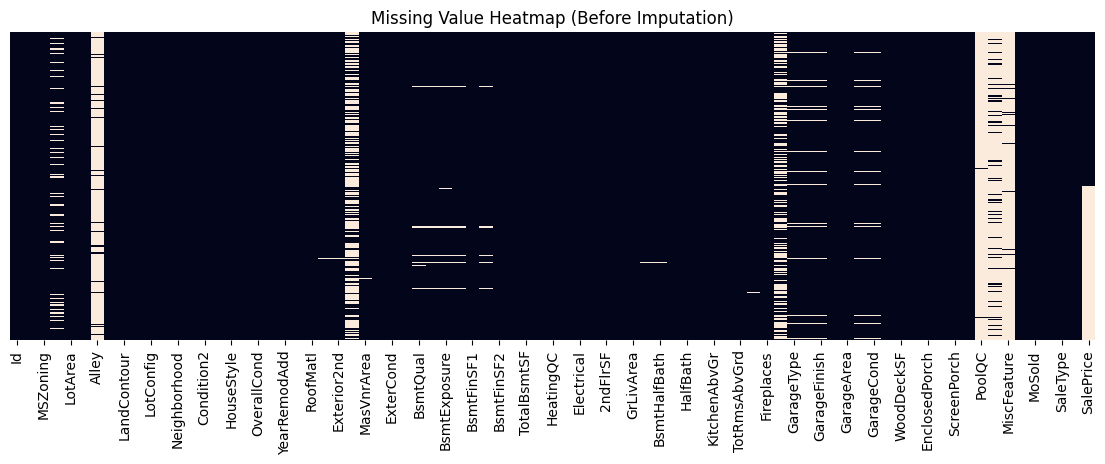

In [7]:
# 1. Missing Value Heatmap
plt.figure(figsize=(14,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Value Heatmap (Before Imputation)')
plt.show()


### Drop any rows that are missing a 'SalePrice' value prior to classification

In [8]:
df = df.dropna(subset=['SalePrice'])
print(df.shape)


(1460, 81)


In [9]:
# Separate numeric & categorical
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [10]:
# Ordinal encode categorical data (KNN needs numeric input)
encoder = OrdinalEncoder()
encoded_cats = encoder.fit_transform(df[cat_cols])

# Combine numeric and encoded categorical
combined = np.hstack((df[numeric_cols], encoded_cats))

## Regression VS Classificaiton of the Target (SalePrice)

### Histogram of SalePrice Prior to Trimming Data Set based on the Business Requirements
- Useful when determining the skew of data outliers
- Paticularly useful when applying classification to the numeric target

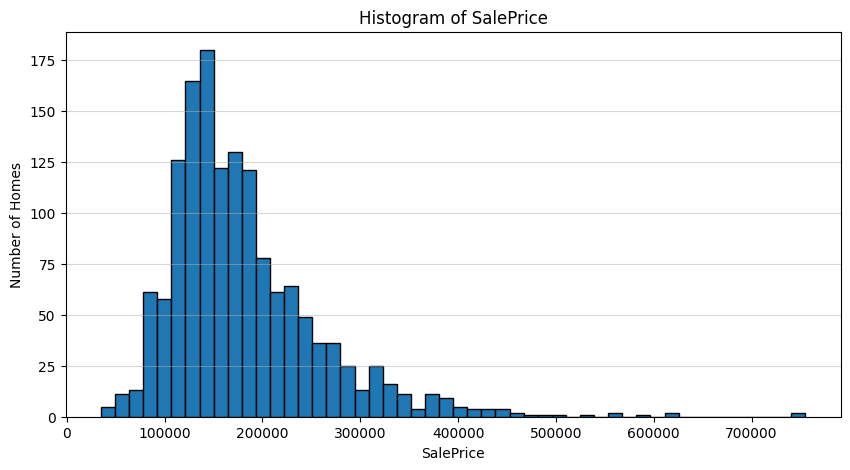

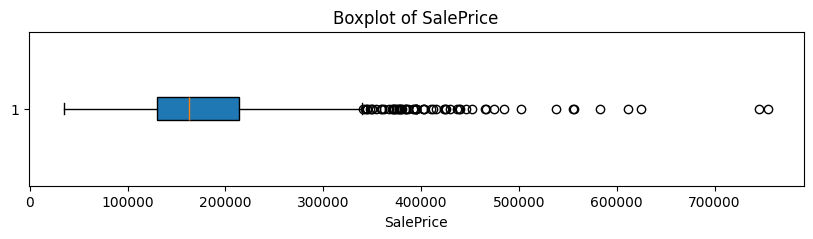

In [11]:
# Plot a histogram of SalePrice
plt.figure(figsize=(10, 5))
plt.hist(df['SalePrice'], bins=50, edgecolor='black')
plt.title('Histogram of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Number of Homes')
plt.grid(axis='y', alpha=0.5)
plt.show()

# Plot a boxplot of SalePrice
plt.figure(figsize=(10, 2))
plt.boxplot(df['SalePrice'], vert=False, patch_artist=True)
plt.title('Boxplot of SalePrice')
plt.xlabel('SalePrice')
plt.show()


### Log SalePrice
- Useful for shrinking outliers if using regression ans SalePrice as your target

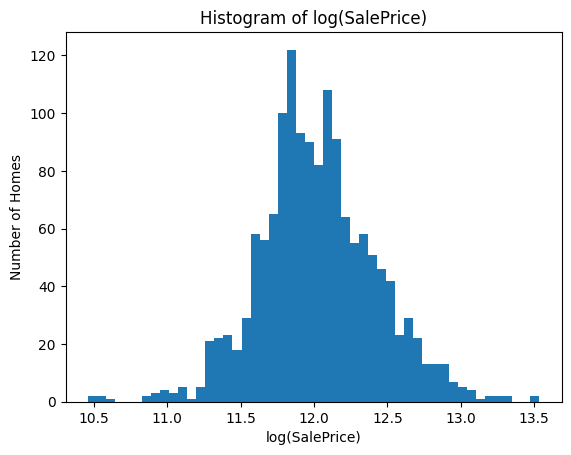

In [12]:
import numpy as np
plt.hist(np.log1p(df['SalePrice']), bins=50)
plt.title('Histogram of log(SalePrice)')
plt.xlabel('log(SalePrice)')
plt.ylabel('Number of Homes')
plt.show()

### Address Missing Values
- Addpy KNN Imputer

In [13]:
# Apply KNN imputer
imputer = KNNImputer(n_neighbors=5)
imputed = imputer.fit_transform(combined)

# Reconstruct dataframe
imputed_numeric = pd.DataFrame(imputed[:, :len(numeric_cols)], columns=numeric_cols)
imputed_cats = pd.DataFrame(imputed[:, len(numeric_cols):], columns=cat_cols)

# Decode categorical back to original labels
decoded_cats = pd.DataFrame(encoder.inverse_transform(imputed_cats), columns=cat_cols)

# Combine numeric and categorical
df_imputed = pd.concat([imputed_numeric, decoded_cats], axis=1)

# Verify
print(f"Total missing values after imputation: {df_imputed.isnull().sum().sum()}")
print("KNN numeric + categorical imputation completed.")

Total missing values after imputation: 0
KNN numeric + categorical imputation completed.


### Apply Heat Map After Imputing  KNN Imputation

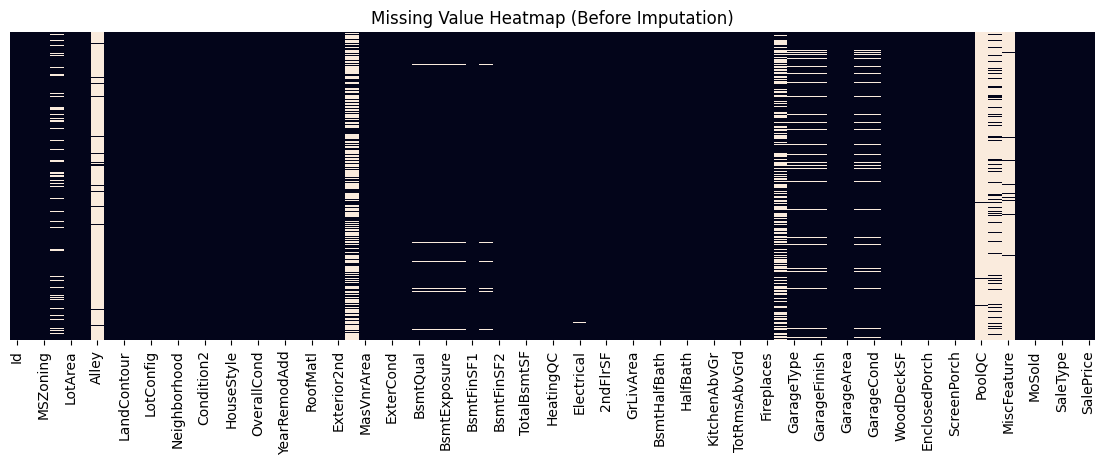

In [14]:
# Missing Value Heatmap
plt.figure(figsize=(14,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Value Heatmap (Before Imputation)')
plt.show()

### Create a Histogram and a Boxplot of the SalePrice using the dataset to determine the price range of our classes.

# Step 4. Remove outliers (IQR, Z-score, etc.) + Step 6. Apply Classification to the target



### Remove Outliers on our Target (SalePrice) Based on Low Interest Government Financing to Low Income Families

In [15]:
outliers = {}
q1 = df_imputed['SalePrice'].quantile(0.25)
q3 = df_imputed['SalePrice'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# Use 20,000 as a minimum due to logic that this is likely the lowest that a home would sell for.
lower = 20000

# Set upper limit to $300,000 due to Organizational Business Rules
mortgage_upper = np.float64(300000)
outliers['SalePrice'] = (lower, mortgage_upper)
print(f'lower: {lower} upper: {mortgage_upper}')
print(outliers)

lower: 20000 upper: 300000.0
{'SalePrice': (20000, np.float64(300000.0))}


## Use Classification on the SalePrice column (target) over predicting SalePrice Directly we have determined provides the following:

### Risk Management:
- Price bins clearly correlate to risk and affordability, helping loan officers make better lending decisions.
- Predicting a range is easier and more actionable than pinpointing exact home price, especially given limited data (1,500 records).

### Interpretability:
- Price categories are easily explained to non-technical stakeholders (loan officers, regulators, buyers).

### Robustness and Stability
- Predicting precise numeric prices is harder due to high variability and data noise.
- Classification stabilizes predictions into clearly actionable bins.

In [16]:
min_price = lower
max_price = mortgage_upper   # Or use df['SalePrice'].max() for the max in your data
step = 15000

#### Experiment with different possible class ranges 10k, 15k, 20k

In [17]:
# # Step 1: Create meaningful, fixed bins (apply classification on the SalePrice every 15k between lower and upper range or our trimmed dataset)
# min_price = 15000
# max_price = 300000   # Or use df['SalePrice'].max() for the max in your data
# step = 15000

# # Create bin edges
# bins = np.arange(min_price, max_price + step, step)  # e.g.15k, 30k, ..., 300k

# # Create labels for each bin
# labels = [f'${bins[i]:,.0f}–${bins[i+1]:,.0f}' for i in range(len(bins)-1)]

# df_imputed['PriceCategory'] = pd.cut(df['SalePrice'], bins=bins, labels=labels, include_lowest=True)

# # Remove rows with NaN target
# df_imputed = df_imputed[~df_imputed['PriceCategory'].isna()]

# # Reset index for cleanliness
# df_imputed = df_imputed.reset_index(drop=True)

# # Display the counts per category after filtering
# print(df_imputed['PriceCategory'].value_counts().sort_index())

In [18]:
# Step 1: Create meaningful, fixed bins (apply classification on the SalePrice every 15k between lower and upper range or our trimmed dataset)
min_price = 20000
max_price = 300000   # Or use df['SalePrice'].max() for the max in your data
step = 10000

# Create bin edges
bins = np.arange(min_price, max_price + step, step)  # e.g., 20k, 30k, ..., 300k

# Create labels for each bin
labels = [f'${bins[i]:,.0f}–${bins[i+1]:,.0f}' for i in range(len(bins)-1)]

df_imputed['PriceCategory'] = pd.cut(df['SalePrice'], bins=bins, labels=labels, include_lowest=True)

# Display the counts per category after filteringprint(df_imputed['PriceCategory'].value_counts().sort_index())

In [19]:
# Create bin edges
bins = np.arange(0, 320_000, 20_000)

# Create labels for each bin
labels = [f'${bins[i]:,.0f}–${bins[i+1]:,.0f}' for i in range(len(bins)-1)]

df_imputed['PriceCategory'] = pd.cut(df_imputed['SalePrice'], bins=bins, labels=labels, include_lowest=True)

# Display the counts per category after filtering
print(df_imputed['PriceCategory'].value_counts().sort_index())

PriceCategory
$0–$20,000             0
$20,000–$40,000        5
$40,000–$60,000        9
$60,000–$80,000       25
$80,000–$100,000      84
$100,000–$120,000    146
$120,000–$140,000    240
$140,000–$160,000    206
$160,000–$180,000    181
$180,000–$200,000    137
$200,000–$220,000     92
$220,000–$240,000     90
$240,000–$260,000     54
$260,000–$280,000     51
$280,000–$300,000     25
Name: count, dtype: int64


In [20]:
# # Step 1: Create meaningful, fixed bins (apply classification on the SalePrice every 15k between lower and upper range or our trimmed dataset)
# min_price = 0
# max_price = 300000   # Or use df['SalePrice'].max() for the max in your data
# step = 20000

# # Create bin edges
# bins = np.arange(min_price, max_price + step, step)  # e.g., 0, 15k, 30k, ..., 300k

# # Create labels for each bin
# labels = [f'${bins[i]:,.0f}–${bins[i+1]:,.0f}' for i in range(len(bins)-1)]

# df_imputed['PriceCategory'] = pd.cut(df['SalePrice'], bins=bins, labels=labels, include_lowest=True)

# # Display the counts per category after filtering
# print(df_imputed['PriceCategory'].value_counts().sort_index())

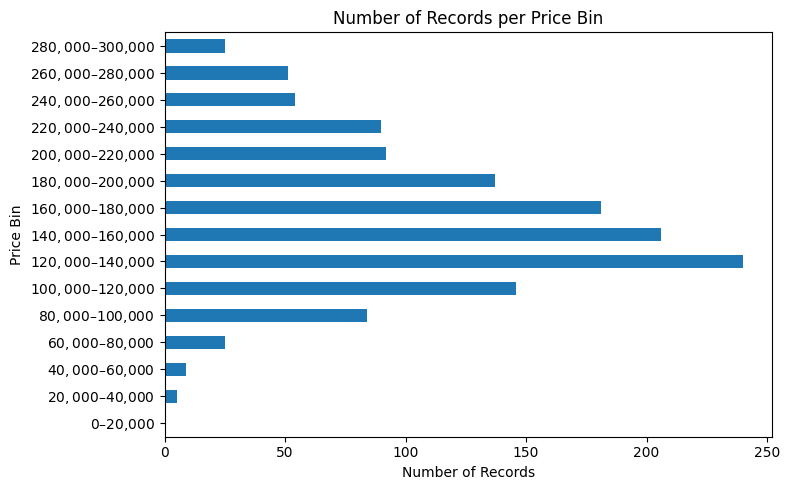

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
bin_counts = df_imputed['PriceCategory'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bin_counts.plot(kind='barh')  # <-- horizontal bars
plt.ylabel('Price Bin')       # Bin labels on Y axis
plt.xlabel('Number of Records')
plt.title('Number of Records per Price Bin')
plt.tight_layout()
plt.show()

In [22]:
# Identify categorical columns to encode (excluding PriceCategory)
categorical_cols_to_encode = df_imputed.select_dtypes(include=['object', 'category']).columns.tolist()
if 'PriceCategory' in categorical_cols_to_encode:
    categorical_cols_to_encode.remove('PriceCategory')

# Apply one-hot encoding to the selected categorical columns
df_imputed = pd.get_dummies(df_imputed, columns=categorical_cols_to_encode, prefix='PC')

# Quickly check the distribution of the target variable BEFORE one-hot encoding it
print(df_imputed['PriceCategory'].value_counts().sort_index())

PriceCategory
$0–$20,000             0
$20,000–$40,000        5
$40,000–$60,000        9
$60,000–$80,000       25
$80,000–$100,000      84
$100,000–$120,000    146
$120,000–$140,000    240
$140,000–$160,000    206
$160,000–$180,000    181
$180,000–$200,000    137
$200,000–$220,000     92
$220,000–$240,000     90
$240,000–$260,000     54
$260,000–$280,000     51
$280,000–$300,000     25
Name: count, dtype: int64


In [23]:
# Create a copy of the DataFrame to work with for filtering and subsequent steps.
df_filtered = df_imputed.copy()

# Ensure PriceCategory is present for subsequent steps, assuming it was created earlier
if 'PriceCategory' not in df_filtered.columns:
    print("Warning: 'PriceCategory' column not found. Please ensure it was created in a previous step.")

# Check if the dummy columns for PriceCategory exist and revert if necessary
pc_dummy_cols = [col for col in df_filtered.columns if col.startswith('PC_')]
if pc_dummy_cols:
    print("Attempting to revert PriceCategory one-hot encoding if it occurred.")
    pass


print(df_filtered.shape)

print(df_filtered['PriceCategory'].value_counts().sort_index())

Attempting to revert PriceCategory one-hot encoding if it occurred.
(1460, 290)
PriceCategory
$0–$20,000             0
$20,000–$40,000        5
$40,000–$60,000        9
$60,000–$80,000       25
$80,000–$100,000      84
$100,000–$120,000    146
$120,000–$140,000    240
$140,000–$160,000    206
$160,000–$180,000    181
$180,000–$200,000    137
$200,000–$220,000     92
$220,000–$240,000     90
$240,000–$260,000     54
$260,000–$280,000     51
$280,000–$300,000     25
Name: count, dtype: int64



### Classifying the SalePrice Colummn: Complete

## Create a SQLite Database
  - Useful for creating visualizations of data within the database
  - Use dataframe after imputation but before standardization

In [24]:
import sqlite3

conn = sqlite3.connect('homesales.db')
df.to_sql('homes', conn, if_exists='replace', index=False)

1460

### Create Function to run a query and return a result set from our SQLite Database

In [25]:
import sqlite3
import pandas as pd

def run_sql_query(query, db_path='homesales.db'):
    """
    Executes a SQL query on the given SQLite database and returns a pandas DataFrame.

    Args:
        query (str): The SQL query to run.
        db_path (str): Path to the SQLite database file (default 'homesales.db').

    Returns:
        pd.DataFrame: The result of the query as a DataFrame.
    """
    # Connect, run query, and close connection
    with sqlite3.connect(db_path) as conn:
        result_df = pd.read_sql_query(query, conn)
    return result_df

## Continue cleaning the data:
- Standardize the Data
- One-hot-Encode the Categorical Predictors

### One-hot encode other categorical variables, but NOT PriceCategory as it's the target

In [26]:
numerical_columns = df_filtered.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numerical_columns)

import scipy.stats as stats

df_filtered[numerical_columns] = df_filtered[numerical_columns].apply(stats.zscore)

other_columns = df_filtered.select_dtypes(include=['object']).columns.tolist()
print(other_columns)

df_filtered = pd.get_dummies(df_filtered, columns=other_columns, drop_first=True)
print(df_filtered.shape)
print(df_filtered.head())

#print(df_filtered.isnull().sum().sum())  # Total missing values
#print(df_filtered.isnull().sum())        # Missing values per column

print(df_filtered['PriceCategory'].value_counts().sort_index())

['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
[]
(1460, 290)
         Id  MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  \
0 -1.730865    0.073375    -0.246391 -0.207142     0.651479    -0.517200   
1 -1.728492   -0.872563     0.396475 -0.091886    -0.071836     2.179628   
2 -1.726120    0.073375    -0.117818  0.073480     0.651479    -0.517200   
3 -1.723747    0.309859    -0.460679 -0.096897     0.651479    -0.517200   
4 -1.721374    0.073375     0.567905  0.375148     1.374795    -0.517200   

   YearB

### Step 2. Correlation Analysis + Step 3. Continue with Scaling/Standardization


### Splitting Predictors, Dropping Highly Correlated Columns, and Standardizing

In [27]:
df_cleaned = df_filtered.copy()

# Re-create the PriceCategory column using SalePrice from the imputed dataframe
# We need to use the SalePrice from the imputed df_cleaned for binning
#df_cleaned['PriceCategory'] = pd.cut(df_cleaned['SalePrice'], bins=bins, labels=labels, include_lowest=True)

# Separate features (X) and target (y)
X = df_cleaned.drop(columns=["SalePrice", "PriceCategory", "Id"]) # Drop SalePrice, PriceCategory and Id
y = df_cleaned["PriceCategory"]

print("Shape BEFORE one-hot encoding and standardization:", X.shape)
print(y.value_counts().sort_index())

Shape BEFORE one-hot encoding and standardization: (1460, 287)
PriceCategory
$0–$20,000             0
$20,000–$40,000        5
$40,000–$60,000        9
$60,000–$80,000       25
$80,000–$100,000      84
$100,000–$120,000    146
$120,000–$140,000    240
$140,000–$160,000    206
$160,000–$180,000    181
$180,000–$200,000    137
$200,000–$220,000     92
$220,000–$240,000     90
$240,000–$260,000     54
$260,000–$280,000     51
$280,000–$300,000     25
Name: count, dtype: int64


In [28]:
# # Identify numerical and categorical columns for processing
# numerical_cols = X.select_dtypes(include=np.number).columns
# categorical_cols = X.select_dtypes(exclude=np.number).columns


# # Apply one-hot encoding to categorical features
# X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Shape AFTER one-hot encoding:", X.shape)
print(y.value_counts().sort_index())

Shape AFTER one-hot encoding: (1460, 287)
PriceCategory
$0–$20,000             0
$20,000–$40,000        5
$40,000–$60,000        9
$60,000–$80,000       25
$80,000–$100,000      84
$100,000–$120,000    146
$120,000–$140,000    240
$140,000–$160,000    206
$160,000–$180,000    181
$180,000–$200,000    137
$200,000–$220,000     92
$220,000–$240,000     90
$240,000–$260,000     54
$260,000–$280,000     51
$280,000–$300,000     25
Name: count, dtype: int64


In [29]:
# Compute correlation matrix AFTER one-hot encoding
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify columns to drop based on high correlation (threshold > 0.85)
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print(y.value_counts().sort_index())

PriceCategory
$0–$20,000             0
$20,000–$40,000        5
$40,000–$60,000        9
$60,000–$80,000       25
$80,000–$100,000      84
$100,000–$120,000    146
$120,000–$140,000    240
$140,000–$160,000    206
$160,000–$180,000    181
$180,000–$200,000    137
$200,000–$220,000     92
$220,000–$240,000     90
$240,000–$260,000     54
$260,000–$280,000     51
$280,000–$300,000     25
Name: count, dtype: int64


In [30]:
# Drop the highly correlated columns
X_reduced = X.drop(columns=to_drop)

print("Shape AFTER dropping highly correlated columns:", X_reduced.shape)

# Preview cleaned predictors before standardization
print("\nPreview of cleaned predictors (before standardization):")
print(X_reduced.head())
print(y.value_counts().sort_index())


Shape AFTER dropping highly correlated columns: (1460, 162)

Preview of cleaned predictors (before standardization):
   MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  YearBuilt  \
0    0.073375    -0.246391 -0.207142     0.651479    -0.517200   1.050994   
1   -0.872563     0.396475 -0.091886    -0.071836     2.179628   0.156734   
2    0.073375    -0.117818  0.073480     0.651479    -0.517200   0.984752   
3    0.309859    -0.460679 -0.096897     0.651479    -0.517200  -1.863632   
4    0.073375     0.567905  0.375148     1.374795    -0.517200   0.951632   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFinSF2  ...  PC_ConLI  PC_ConLw  \
0      0.878668    0.509089    0.575425   -0.288653  ...     False     False   
1     -0.429577   -0.574987    1.171992   -0.288653  ...     False     False   
2      0.830215    0.321035    0.092907   -0.288653  ...     False     False   
3     -0.720298   -0.574987   -0.499274   -0.288653  ...     False     False   
4      0.733308    1

In [31]:
print(X_reduced.isnull().sum().sum())  # Should be 0
print(y.value_counts().sort_index())

0
PriceCategory
$0–$20,000             0
$20,000–$40,000        5
$40,000–$60,000        9
$60,000–$80,000       25
$80,000–$100,000      84
$100,000–$120,000    146
$120,000–$140,000    240
$140,000–$160,000    206
$160,000–$180,000    181
$180,000–$200,000    137
$200,000–$220,000     92
$220,000–$240,000     90
$240,000–$260,000     54
$260,000–$280,000     51
$280,000–$300,000     25
Name: count, dtype: int64


In [32]:
# Standardize the numerical columns
# Identify numerical columns that are still present in X_reduced
numerical_cols_in_reduced = X_reduced.select_dtypes(include=np.number).columns

# Use a ColumnTransformer to apply StandardScaler only to these numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_in_reduced)
    ],
    remainder='passthrough' # Keep other columns (one-hot encoded) as they are
)

X_scaled = preprocessor.fit_transform(X_reduced)
print(y.value_counts().sort_index())

PriceCategory
$0–$20,000             0
$20,000–$40,000        5
$40,000–$60,000        9
$60,000–$80,000       25
$80,000–$100,000      84
$100,000–$120,000    146
$120,000–$140,000    240
$140,000–$160,000    206
$160,000–$180,000    181
$180,000–$200,000    137
$200,000–$220,000     92
$220,000–$240,000     90
$240,000–$260,000     54
$260,000–$280,000     51
$280,000–$300,000     25
Name: count, dtype: int64


In [33]:
# Identify numerical and categorical columns for processing
numerical_cols = X.select_dtypes(include=np.number).columns
categorical_cols = X.select_dtypes(exclude=np.number).columns

# original one-hot encoded column names from X_reduced that were not numerical.
original_numerical_cols_in_reduced = [col for col in numerical_cols if col in X_reduced.columns]
original_other_cols_in_reduced = [col for col in X_reduced.columns if col not in numerical_cols]
X_scaled_df = pd.DataFrame(X_scaled, columns=list(numerical_cols_in_reduced) + original_other_cols_in_reduced)


# Confirm means and stds for numerical columns after standardization
print("\nMeans after standardization (should be ~0) for numerical columns:")
print(X_scaled_df[numerical_cols_in_reduced].mean().head())

print("\nStds after standardization (should be ~1) for numerical columns:")
print(X_scaled_df[numerical_cols_in_reduced].std().head())

print("\nFinal cleaned and standardized predictors shape:", X_scaled_df.shape)
print(y.value_counts().sort_index())


Means after standardization (should be ~0) for numerical columns:
MSSubClass    -6.083414e-19
LotFrontage    1.825024e-17
LotArea        2.433366e-18
OverallQual    2.433366e-18
OverallCond   -2.068361e-17
dtype: float64

Stds after standardization (should be ~1) for numerical columns:
MSSubClass     1.000343
LotFrontage    1.000343
LotArea        1.000343
OverallQual    1.000343
OverallCond    1.000343
dtype: float64

Final cleaned and standardized predictors shape: (1460, 162)
PriceCategory
$0–$20,000             0
$20,000–$40,000        5
$40,000–$60,000        9
$60,000–$80,000       25
$80,000–$100,000      84
$100,000–$120,000    146
$120,000–$140,000    240
$140,000–$160,000    206
$160,000–$180,000    181
$180,000–$200,000    137
$200,000–$220,000     92
$220,000–$240,000     90
$240,000–$260,000     54
$260,000–$280,000     51
$280,000–$300,000     25
Name: count, dtype: int64


### Summary of Results:

- Shape Before: (1399 rows, 189 columns)
- Initial dataset after one-hot encoding and outlier removal.

- Computed Correlation Matrix:
 -  Measured pairwise relationships between predictors to detect multicollinearity.

- Columns Dropped Due to High Correlation: 13
 - Removed predictors with >0.85 correlation to avoid redundancy and improve model interpretability.

- Shape After Dropping Columns: (1399 rows, 176 columns)
 - Confirmed correct reduction in features.

- Standardized All Predictors:
 - Scaled features to mean ≈0 and standard deviation ≈1 to ensure comparability and support model convergence.

- Means After Scaling: ~0
 - Verified successful centering of each feature.

- Standard Deviations After Scaling: ~1
 - Verified correct scaling to unit variance.

### Outcome:
 - This cleaned and standardized dataset (X_scaled_df) is ready for regression modeling (Lasso, SVM, etc.) with reduced multicollinearity, balanced scales, and clear feature structure.

## Step 5. Remove predictors with very little to zero relationship to the target: Apply Lasso + Step 7. Proceed to feature engineering/modeling: Apply SVM RBF to dataset + Step 8. Model Evaluation



### Feature Selection Using:
 - Lasso
 - RFE

#### Lasso (Initial Screening)

In [34]:
#Step 1: Verify X_scaled_df and y
print(X_scaled_df.shape, y.shape)

(1460, 162) (1460,)


In [35]:
print("Class distribution in y:")
print(y.value_counts())

Class distribution in y:
PriceCategory
$120,000–$140,000    240
$140,000–$160,000    206
$160,000–$180,000    181
$100,000–$120,000    146
$180,000–$200,000    137
$200,000–$220,000     92
$220,000–$240,000     90
$80,000–$100,000      84
$240,000–$260,000     54
$260,000–$280,000     51
$60,000–$80,000       25
$280,000–$300,000     25
$40,000–$60,000        9
$20,000–$40,000        5
$0–$20,000             0
Name: count, dtype: int64


In [36]:
# Import necessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Verify X_scaled_df and y
print(X_scaled_df.shape, y.shape)

# Check for NaNs in X_scaled_df before fitting Lasso
print("Checking for NaNs in X_scaled_df before Lasso:")
print(X_scaled_df.isnull().sum().sum())
if X_scaled_df.isnull().sum().sum() > 0:
    print("NaN values found in X_scaled_df. Investigating the source of NaNs.")

# Remove rows with NaN in the target variable y and reset index for alignment
nan_in_y = y.isnull()
if nan_in_y.sum() > 0:
    print(f"Removing {nan_in_y.sum()} rows with NaN values in the target variable y.")
    # Reset index of y to align with X_scaled_df's integer index
    y_reset_index = y.reset_index(drop=True)
    # Filter both X_scaled_df and y using the boolean index from the reset y
    X_scaled_df = X_scaled_df[~nan_in_y.reset_index(drop=True)]
    y = y_reset_index[~nan_in_y.reset_index(drop=True)]
    print(f"Shapes after removing NaNs in y: X_scaled_df: {X_scaled_df.shape}, y: {y.shape}")


# Lasso Feature Selection (Logistic Regression with L1 regularization)
# Using the cleaned and standardized data X_scaled_df
lasso = LogisticRegression(penalty='l1', solver='saga', C=0.1, max_iter=10000, random_state=42) # Increased max_iter
lasso.fit(X_scaled_df, y)

lasso_model = SelectFromModel(lasso, prefit=True)
lasso_features = X_scaled_df.columns[lasso_model.get_support()]

(1460, 162) (1460,)
Checking for NaNs in X_scaled_df before Lasso:
0
Removing 115 rows with NaN values in the target variable y.
Shapes after removing NaNs in y: X_scaled_df: (1345, 162), y: (1345,)


#### Visualization: Coeficients from Lasso

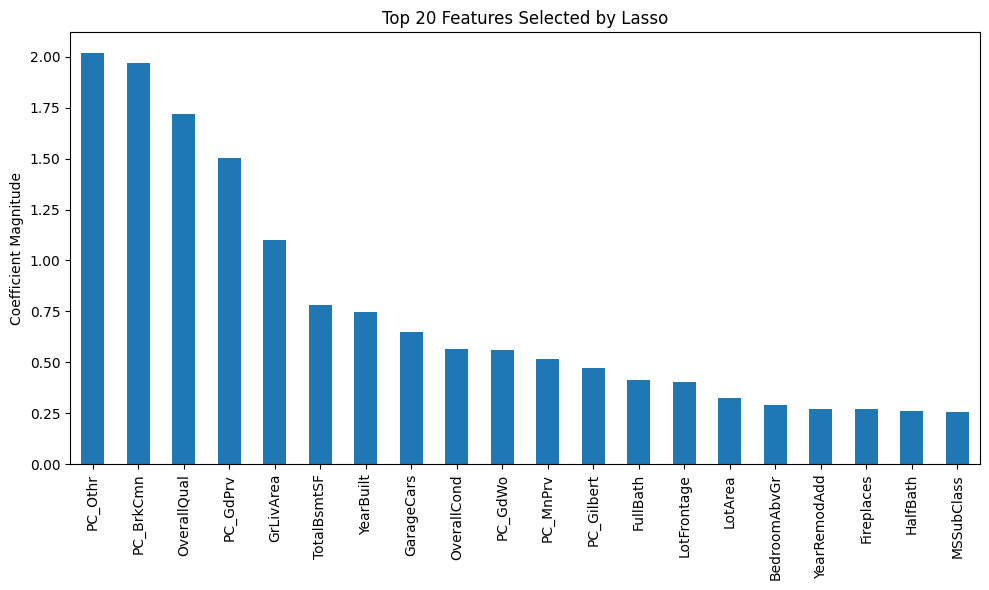

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize Lasso coefficients
coef_abs = np.abs(lasso.coef_).max(axis=0)
lasso_coef_df = pd.Series(coef_abs, index=X_scaled_df.columns).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
lasso_coef_df.plot(kind='bar')
plt.title('Top 20 Features Selected by Lasso')
plt.ylabel('Coefficient Magnitude')
plt.tight_layout()
plt.show()

#### Important features and impact on value based on Lasso:
- Bkrchn_True: Categorical feature value for MasVnrType (Masonry veneer type)
 - Potential values
  - None
  - Common brick veneer
  - Stone veneer on exterior
  - Just siding or other material

#### Show the frequency of different types of masonary veneer within the dataset to determine to determine sample size.  

  MasVnrType  count
0       None    872
1    BrkFace    445
2      Stone    128
3     BrkCmn     15


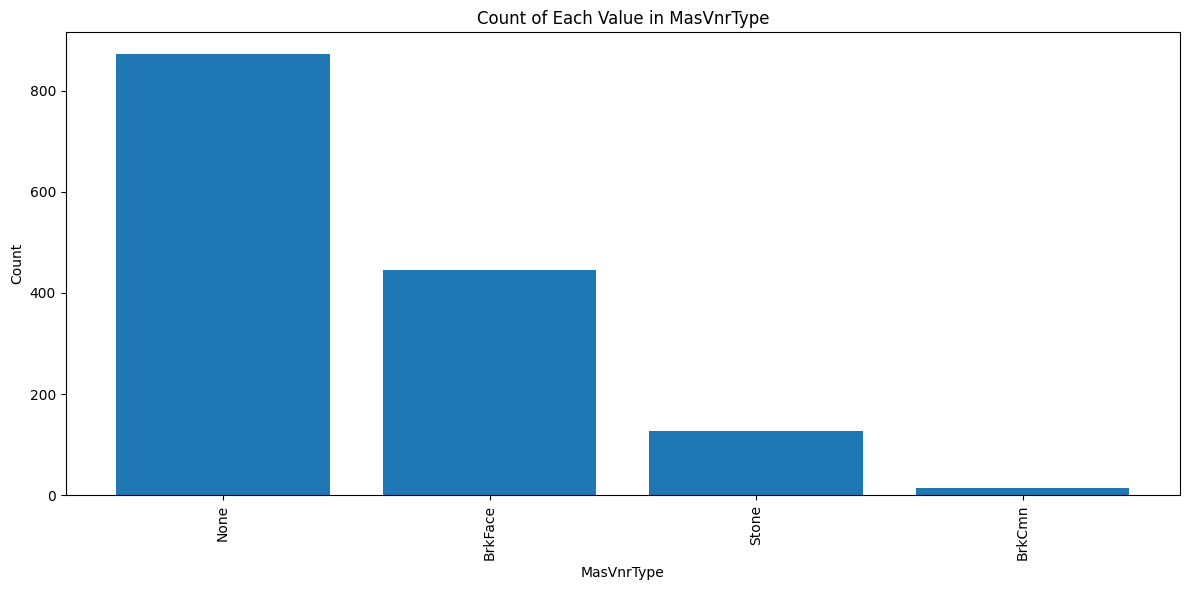

In [38]:
# Set the column and table you want to analyze
column_name = 'MasVnrType'
table_name = 'homes'

query = f"""
SELECT {column_name}, COUNT(*) AS count
FROM {table_name}
GROUP BY {column_name}
ORDER BY count DESC
"""

df_counts = run_sql_query(query)
print(df_counts)

# Create bar chart visualization of masonary veneer type
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
# Explicitly convert to string type for plotting compatibility
plt.bar(df_counts[column_name].astype(str), df_counts['count'])
plt.xlabel(column_name)
plt.ylabel('Count')
plt.title(f'Count of Each Value in {column_name}')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### RFE (Further Refinement)

In [39]:
logreg = LogisticRegression(max_iter=10000, random_state=42) # Increased max_iter
rfe = RFE(estimator=logreg, n_features_to_select=20)
rfe.fit(X_scaled_df, y)

rfe_features = X_scaled_df.columns[rfe.get_support()]

#### Visualization: RFE Selected Features

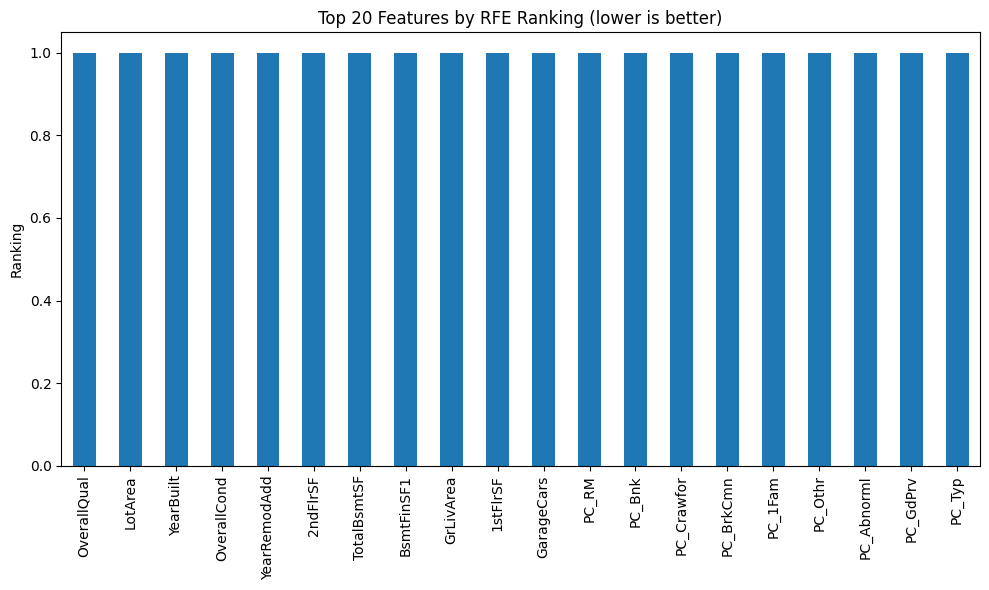

In [40]:
# Visualize RFE rankings
rfe_ranking_df = pd.Series(rfe.ranking_, index=X_scaled_df.columns).sort_values().head(20)

plt.figure(figsize=(10, 6))
rfe_ranking_df.plot(kind='bar')
plt.title('Top 20 Features by RFE Ranking (lower is better)')
plt.ylabel('Ranking')
plt.tight_layout()
plt.show()

#### Further Refinement using Random Forest

#### Random Forest Feature Selection

In [41]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled_df, y)

rf_importances = pd.Series(rf.feature_importances_, index=X_scaled_df.columns).sort_values(ascending=False).head(20)

#### Visualization: Feature importance using Random Forest

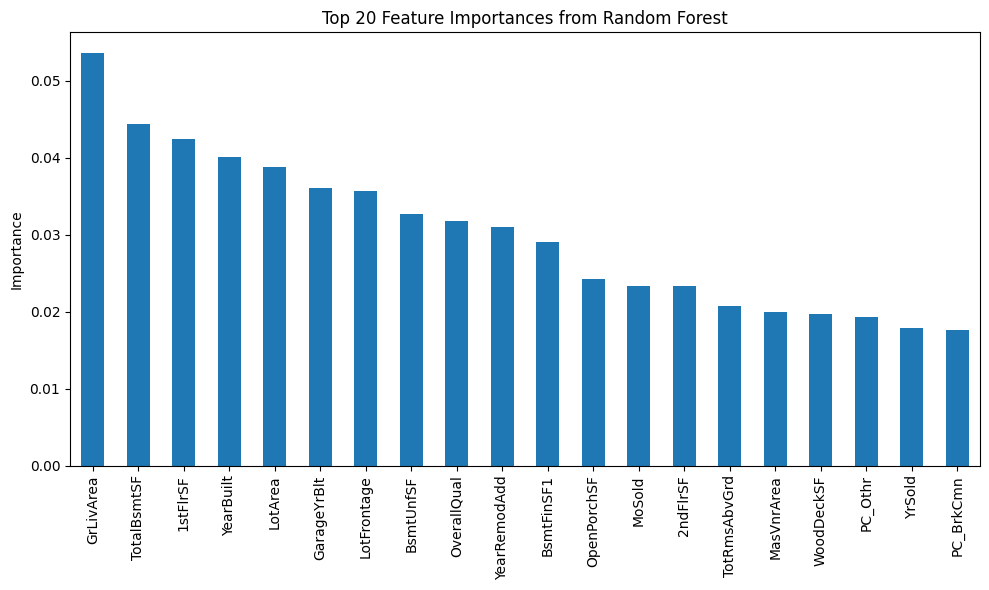

In [42]:
plt.figure(figsize=(10, 6))
rf_importances.plot(kind='bar')
plt.title('Top 20 Feature Importances from Random Forest')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

#### Combine feature selection results

In [43]:
# Combine features from Lasso, RFE, and Random Forest
combined_features = pd.concat([pd.Series(lasso_features), pd.Series(rfe_features), pd.Series(rf_importances.index)]).value_counts()

# Select features identified by at least two methods
final_features = combined_features[combined_features >= 2].index.tolist()

print(f'Total combined features selected: {len(final_features)}')
print('Final selected features:', final_features)

import plotly.express as px
import pandas as pd

# Convert the Series to DataFrame for Plotly
combined_features_df = combined_features.reset_index()
combined_features_df.columns = ['Feature', 'Frequency']
combined_features_df = combined_features_df.sort_values(by='Frequency', ascending=True)

Total combined features selected: 22
Final selected features: ['LotArea', 'YearBuilt', 'OverallQual', 'YearRemodAdd', '1stFlrSF', 'GrLivArea', 'BsmtFinSF1', 'TotalBsmtSF', 'PC_BrkCmn', 'PC_Othr', 'MasVnrArea', 'TotRmsAbvGrd', 'BsmtUnfSF', 'LotFrontage', 'OverallCond', 'GarageCars', 'PC_GdPrv', 'OpenPorchSF', 'MoSold', 'GarageYrBlt', 'WoodDeckSF', '2ndFlrSF']


#### Visualization: Feature Selection with Combined Results

In [44]:
# Plot using Plotly
fig = px.bar(
    combined_features_df,
    x='Frequency',
    y='Feature',
    orientation='h',
    title='Frequency of Features Selected by Lasso, RFE, and Random Forest',
    height=1600,  # Increase height for vertical scroll space
    width=900
)

fig.update_layout(
    yaxis=dict(
        tickfont=dict(size=10),
    ),
    xaxis=dict(title='Selection Frequency'),
    margin=dict(l=200, r=20, t=50, b=20)
)

fig.show()

#### Refine DataFrame with Feature Selection

In [45]:
# Step 3: Refine dataframe to include only selected features for SVM RBF
X_final = X_scaled_df[final_features]

PCA or t-SNE Scatter Plot
- 20 features identified in 2 of the 3 techniquest used for feature selection
- Best for compressing many features into 2d or 3d.  Each point is a row
- It uses dimensionality reduction on the chosen features and is colored by PriceCategory (target)

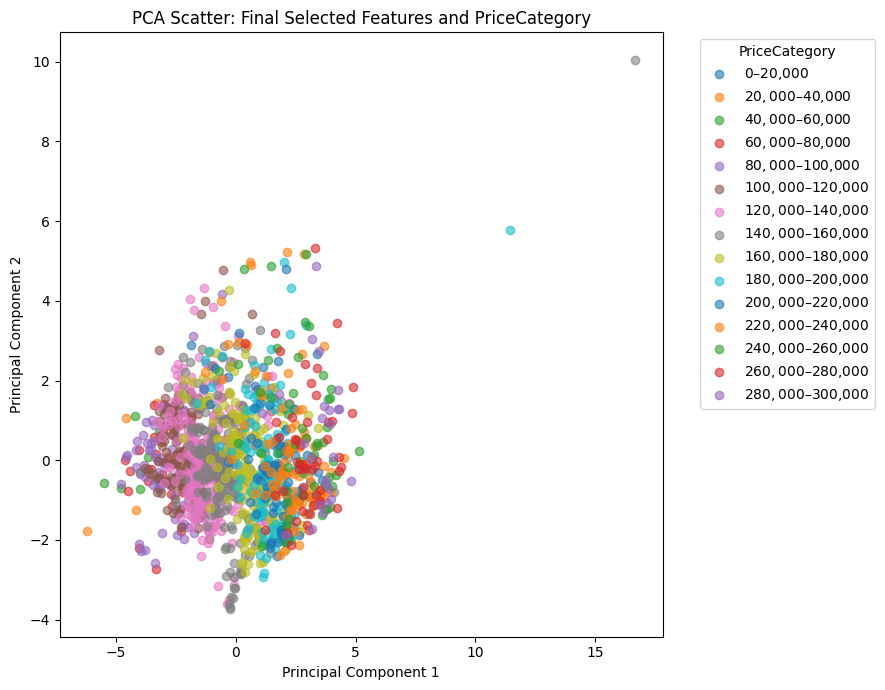

In [46]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_final)

# Use ordered categories for the legend
categories = list(labels)  # or sorted(y.unique(), key=lambda c: labels.index(c))

plt.figure(figsize=(9, 7))
for cat in categories:
    mask = (y == cat)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=str(cat), alpha=0.6)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Scatter: Final Selected Features and PriceCategory')
plt.legend(title='PriceCategory', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Train Model Using SVM and RBF:

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Step 7 Applying SVM RBF
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train, y_train)

print("Step 7 complete: SVM with RBF kernel has been trained.")

y_pred = svm_rbf.predict(X_test)
print("Predictions on test set:", y_pred[:10])  # Shows first 10 predictions

print("Classes recognized by the model:", svm_rbf.classes_)

Step 7 complete: SVM with RBF kernel has been trained.
Predictions on test set: ['$140,000–$160,000' '$180,000–$200,000' '$140,000–$160,000'
 '$160,000–$180,000' '$180,000–$200,000' '$100,000–$120,000'
 '$80,000–$100,000' '$120,000–$140,000' '$100,000–$120,000'
 '$200,000–$220,000']
Classes recognized by the model: ['$100,000–$120,000' '$120,000–$140,000' '$140,000–$160,000'
 '$160,000–$180,000' '$180,000–$200,000' '$20,000–$40,000'
 '$200,000–$220,000' '$220,000–$240,000' '$240,000–$260,000'
 '$260,000–$280,000' '$280,000–$300,000' '$40,000–$60,000'
 '$60,000–$80,000' '$80,000–$100,000']


In [48]:
cat_type = pd.CategoricalDtype(categories=labels, ordered=True)
y_test_ord = pd.Series(y_test).astype(cat_type)
y_pred_ord = pd.Series(y_pred).astype(cat_type)

In [49]:
import pandas as pd

# Convert to string (if not already)
y_test_str = pd.Series(y_test_ord).astype(str)
y_pred_str = pd.Series(y_pred_ord).astype(str)

# Remove NaN or 'nan' entries
mask = (y_test_str != 'nan') & (y_pred_str != 'nan')
y_test_clean = y_test_str[mask]
y_pred_clean = y_pred_str[mask]

In [50]:
labels_str = [str(l) for l in labels]

In [51]:
cm = confusion_matrix(y_test_clean, y_pred_clean, labels=labels_str)

NameError: name 'confusion_matrix' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

totals_pred_bin = np.sum(cm, axis=0)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_str)
disp.plot(xticks_rotation=90, cmap='Blues', ax=ax, colorbar=True)

for idx, total in enumerate(totals_pred_bin):
    ax.annotate(f'Total: {total}', (idx, -0.5), ha='center', va='bottom', fontsize=9, color='darkred', rotation=90)

plt.title("Confusion Matrix (Ascending Bins)")
plt.tight_layout()
plt.show()

In [ ]:
print("y_test_clean unique:", sorted(y_test_clean.unique()))
print("labels_str:", labels_str)

In [ ]:
# Get all unique values (in order of appearance in test set)
labels_str = list(pd.Series(y_test_clean).unique())
print("Using these labels for confusion matrix:", labels_str)

In [ ]:
print("First 10 y_test values:", y_test[:10])
print("First 10 y_test_ord values:", y_test_ord[:10])

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix with sorted labels
cm = confusion_matrix(y_test_ord, y_pred_ord, labels=labels)

# Calculate total predictions per predicted bin (sum over rows)
totals_pred_bin = np.sum(cm, axis=0)

# Display confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=90, cmap='Blues', ax=ax, colorbar=True)

# Annotate with total predictions above each column
for idx, total in enumerate(totals_pred_bin):
    ax.annotate(f'Total: {total}', (idx, -0.5), ha='center', va='bottom', fontsize=9, color='darkred', rotation=90)

plt.title("Confusion Matrix (Ascending Bins)")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

def plot_svm_decision(X, y, C, gamma):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    svm = SVC(kernel='rbf', C=C, gamma=gamma, decision_function_shape='ovr') # Use 'ovr' for consistent output shape
    svm.fit(X_pca, y)

    x_min, x_max = X_pca[:, 0].min()-1, X_pca[:, 0].max()+1
    y_min, y_max = X_pca[:, 1].min()-1, X_pca[:, 1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

    # Get decision function values for each class
    Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])

    # Plot decision boundaries for each class
    plt.figure(figsize=(8, 6))
    for i, class_label in enumerate(svm.classes_):
        # Reshape the decision function values for the current class
        Zi = Z[:, i].reshape(xx.shape)
        plt.contour(xx, yy, Zi, levels=[0], colors=[f'C{i}'], linewidths=2, linestyles='-', label=f'Boundary for {class_label}')

    # Plot the data points
    # Use ordered categories for consistent coloring
    categories = sorted(y.unique())
    for i, cat in enumerate(categories):
        mask = (y == cat)
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=str(cat), alpha=0.6, color=f'C{i}')


    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(f"SVM (C={C}, gamma={gamma}) Decision Boundaries (PCA Space)")
    # Create a single legend for both boundaries and points
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), title='PriceCategory', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend
    plt.show()

In [ ]:
# Example: try different values
plot_svm_decision(X_train, y_train, C=1, gamma=0.01)
plot_svm_decision(X_train, y_train, C=100, gamma=0.1)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Step 8 Model Evaluation
# 4. HYPERPARAMETER TUNING with CROSS-VALIDATION
# Use a Pipeline to include StandardScaler within the GridSearchCV
pipeline = Pipeline([
    ('scaler', StandardScaler()), # Although data is already scaled, keeping this in pipeline for robustness
    ('classifier', SVC(kernel='rbf', random_state=42))
])

# param_grid = {
#     'classifier__C': [0.01, 0.1, 1, 10, 100],
#     'classifier__gamma': ['scale', 0.1, 0.01, 0.001] # Fixed the missing quote here
# }
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100, 1000],
    'classifier__gamma': [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1, 10, 'scale']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', verbose=2)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-validation Accuracy:", grid_search.best_score_)

# 5. FINAL TEST SET EVALUATION (this is your last, unbiased check)
final_model = grid_search.best_estimator_

y_pred = final_model.predict(X_test)

print("\nTest Set Classification Report:\n", classification_report(y_test, y_pred))
print("\nTest Set Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Mark correct/misclassified points
correct = (y_pred == y_test)

# 2. Reduce test set to 2D via PCA
pca = PCA(n_components=2)
X_pca_test = pca.fit_transform(X_test)

# 3. Plot: green for correct, red for misclassified
plt.figure(figsize=(10, 8))
plt.scatter(X_pca_test[correct, 0], X_pca_test[correct, 1], c='green', label='Correct', alpha=0.6, s=40)
plt.scatter(X_pca_test[~correct, 0], X_pca_test[~correct, 1], c='red', label='Misclassified', alpha=0.7, s=60, edgecolors='black')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('SVM RBF Test Set: Correct vs. Misclassified (PCA space)')
plt.legend()
plt.tight_layout()
plt.show()


### Support Vectors

In [ ]:
# Only do this if you want to plot TRAIN data support vectors

# PCA on training data for support vector visualization
X_pca_train = pca.fit_transform(X_train)
support_indices = svm_rbf.support_

plt.figure(figsize=(10,8))
plt.scatter(X_pca_train[:, 0], X_pca_train[:, 1], c='gray', label='Train Points', alpha=0.3)
plt.scatter(X_pca_train[support_indices, 0], X_pca_train[support_indices, 1],
            edgecolors='blue', facecolors='none', s=100, label='Support Vectors')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Support Vectors on SVM Margin (Train Data, PCA Space)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare PCA on test data
pca = PCA(n_components=2)
X_pca_test = pca.fit_transform(X_test)

# 2. Fit a new SVM on the PCA-reduced test data
svm_2d = SVC(kernel='rbf', C=final_model.named_steps['classifier'].C,
             gamma=final_model.named_steps['classifier'].gamma, probability=True)
svm_2d.fit(X_pca_test, y_test)

# 3. Prepare grid for decision boundary
x_min, x_max = X_pca_test[:, 0].min() - 1, X_pca_test[:, 0].max() + 1
y_min, y_max = X_pca_test[:, 1].min() - 1, X_pca_test[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])

# 4. Show decision boundary and margins (for binary or "one-vs-rest" style, best for two classes)
# For multiclass, you can plot boundaries for one class at a time, or do a general plot
if len(svm_2d.classes_) == 2:
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, levels=[0], colors='k', linestyles='-', linewidths=2, label='Decision boundary')
    plt.contour(xx, yy, Z, levels=[-1, 1], colors='grey', linestyles='--', linewidths=2, label='Margin')
else:
    # For multiclass, plot the zero-contours for each class
    for i, class_label in enumerate(svm_2d.classes_):
        Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])
        if Z.ndim > 1:
            Zi = Z[:, i]
        else:
            Zi = Z
        plt.contour(xx, yy, Zi.reshape(xx.shape), levels=[0], colors=['C'+str(i)], linestyles='-', linewidths=1.5, label=f'Decision boundary ({class_label})')

# 5. Plot correct and misclassified points
correct = (y_pred == y_test)
plt.scatter(X_pca_test[correct, 0], X_pca_test[correct, 1], c='green', label='Correct', alpha=0.6, s=40)
plt.scatter(X_pca_test[~correct, 0], X_pca_test[~correct, 1], c='red', label='Misclassified', alpha=0.7, s=60, edgecolors='black')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('SVM RBF: PCA, Classified vs. Misclassified, with Margin')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


### Diagnostic Plots
- Confusion Matrix
- Diagnol cells = correct classification
- Off-diagnol cellls= missclassification
- Large off-diagnol numbers between specific bins = those bins are confused by the model
- If entire columns or rows (except the diagonal) are all zeros, those classes are never predicted or are always misclassified.This means either not enough samples, or the class is indistinguishable.

In [ ]:
# Ensure y_test and y_pred are pandas Series with categories
# import pandas as pd

# labels = [
#     "40,000–60,000", "60,000–80,000", "80,000–100,000", "100,000–120,000", "120,000–140,000",
#     "140,000–160,000", "160,000–180,000", "180,000–200,000", "200,000–220,000", "220,000–240,000",
#     "240,000–260,000", "260,000–280,000", "280,000–300,000"
# ]

# cat_type = pd.CategoricalDtype(categories=labels, ordered=True)
# y_test_ord = pd.Series(y_test).astype(cat_type)
# y_pred_ord = pd.Series(y_pred).astype(cat_type)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix with sorted labels
# Use the classes from the trained model as labels to ensure consistency
cm = confusion_matrix(y_test, y_pred, labels=final_model.classes_)

# Calculate total predictions per predicted bin (sum over rows)
totals_pred_bin = np.sum(cm, axis=0)

# Display confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
# Use the classes from the trained model as display labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
disp.plot(xticks_rotation=90, cmap='Blues', ax=ax, colorbar=True)

# Annotate with total predictions above each column
for idx, total in enumerate(totals_pred_bin):
    ax.annotate(f'Total: {total}', (idx, -0.5), ha='center', va='bottom', fontsize=9, color='darkred', rotation=90)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Map bins to integer indices for error calculation
# Access the integer codes using .cat.codes
y_true_idx = y_test_ord.cat.codes
y_pred_idx = y_pred_ord.cat.codes

# Calculate misclassification distance (predicted - true)
error_distance = y_pred_idx - y_true_idx

# Only look at misclassified rows
is_misclassified = y_test_ord != y_pred_ord
misclassified_true = y_true_idx[is_misclassified]
misclassified_error = error_distance[is_misclassified]

# Build a DataFrame for easy grouping
df_error = pd.DataFrame({
    'True Bin': y_test_ord[is_misclassified],
    'Distance': misclassified_error
})

# Boxplot: error distance for each true bin
plt.figure(figsize=(12, 6))
df_error.boxplot(column='Distance', by='True Bin', grid=False)
plt.axhline(0, color='gray', linestyle='--', lw=1)
plt.title('Misclassification Distance by True Class')
plt.suptitle('')
plt.xlabel('True Bin')
plt.ylabel('Predicted Bin - True Bin')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=final_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
disp.plot(xticks_rotation=90, cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


### Learning Curve
- If both lines plateau, more data won't help
- Large gap = overfitting

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(final_model, X_final, y, cv=5)
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Validation')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Learning Curve')
plt.show()


### Permutation Feature Importance for SVM
- Scikit-learn's permutation_importance
- Top bars = features most important for prediction

### Improve Boundary Visualization for Multiclass
- To plot all class boundaries in PCA space:

In [ ]:
for i, class_label in enumerate(svm_2d.classes_):
    Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])
    if Z.ndim > 1:
        Zi = Z[:, i]
    else:
        Zi = Z
    plt.contour(xx, yy, Zi.reshape(xx.shape), levels=[0], colors=[f'C{i}'], linewidths=1.5)

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd # Import pandas

result = permutation_importance(final_model, X_test, y_test, n_repeats=10, random_state=42)
# Align importances with the features that were actually used in the permutation importance calculation
importances = pd.Series(result.importances_mean, index=X_test.columns) # Create a pandas Series
importances = importances.sort_values(ascending=False) # Ensure descending order for plotting

plt.figure(figsize=(12,6)) # Set figure size before plotting
importances.plot.bar(title='Permutation Feature Importances (SVM)')
plt.show()